<a href="https://colab.research.google.com/github/Abdullahcys10/MachineLearning6my2/blob/main/lab10/02_SVM_Assignment_c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Support Vector Machines (SVM) – Iris Dataset Assignment
In this assignment we will use the classic **Iris** dataset to practice building and
tuning a Support Vector Classifier (SVC). We will walk through:
1. Exploratory data analysis (pairplot, KDE)
2. Train/test split
3. Default SVC model and evaluation
4. Hyperparameter tuning with `GridSearchCV`
5. Comparison of results


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

%matplotlib inline

## 2. Load the Iris Dataset

We load the Iris dataset via **seaborn** (requires internet) or fall back to
scikit-learn's built-in copy, then build a tidy DataFrame with column names that
match the seaborn version.


In [2]:
# Try seaborn first (requires internet); fall back to sklearn built-in
try:
    iris = sns.load_dataset('iris')
except Exception:
    iris_sk = load_iris()
    iris = pd.DataFrame(
        iris_sk.data,
        columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
    )
    iris['species'] = pd.Categorical.from_codes(iris_sk.target, iris_sk.target_names)

print(iris.shape)
iris.head()

(150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Pairplot – Visualise All Feature Pairs

A pairplot lets us quickly see which pairs of features best separate the three species.


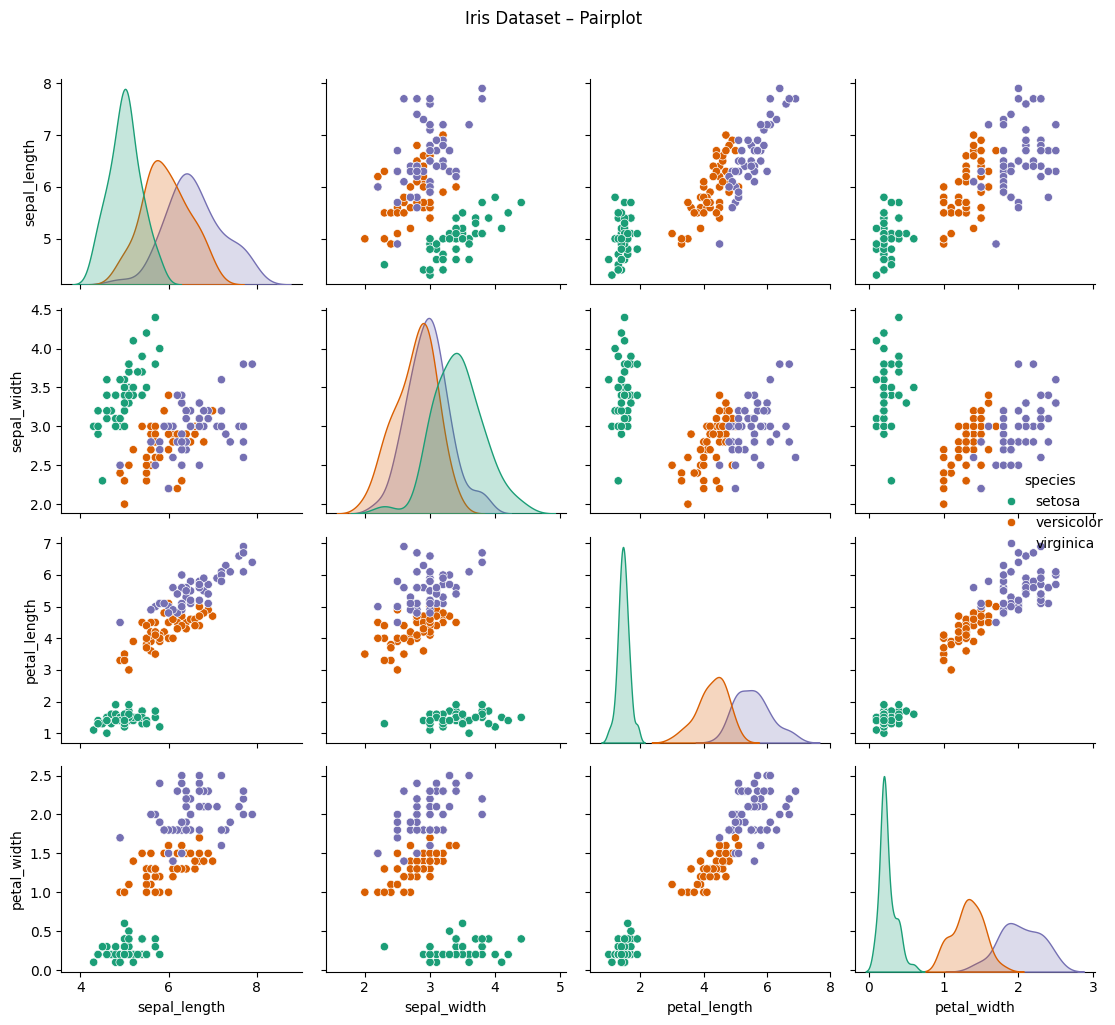

In [3]:
sns.pairplot(iris, hue='species', palette='Dark2')
plt.suptitle('Iris Dataset – Pairplot', y=1.02)
plt.tight_layout()
plt.show()

### Observation
**Setosa** is the most linearly separable species — it forms a tight, well-isolated
cluster in every feature-pair plot, especially in the *petal_length* vs *petal_width*
panel. Versicolor and virginica overlap slightly, making them harder to separate,
but petal features still provide a good boundary between them.


## 4. KDE Plot – Setosa: Sepal Length vs Sepal Width

A 2-D kernel density estimate shows the joint distribution of sepal dimensions
for the setosa species.


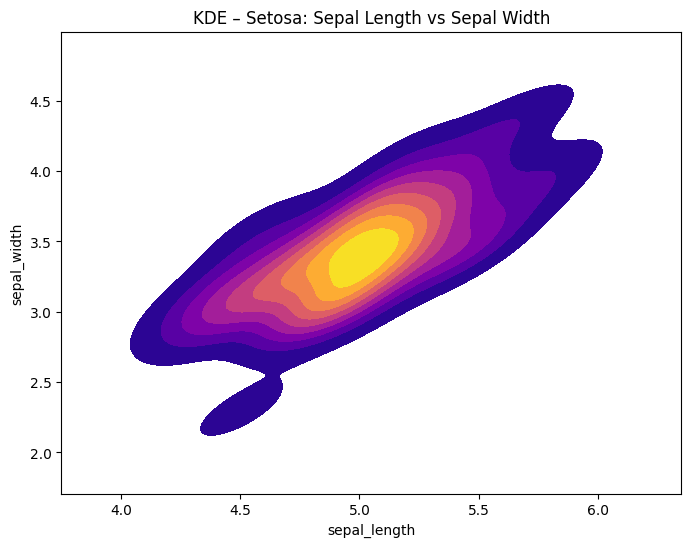

In [4]:
setosa = iris[iris['species'] == 'setosa']

fig, ax = plt.subplots(figsize=(8, 6))
sns.kdeplot(
    data=setosa,
    x='sepal_length',
    y='sepal_width',
    fill=True,
    cmap='plasma',
    ax=ax
)
ax.set_title('KDE – Setosa: Sepal Length vs Sepal Width')
plt.show()

## 5. Train / Test Split


In [5]:
X = iris.drop('species', axis=1)
y = iris['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=101
)

print(f'Training set: {X_train.shape}')
print(f'Test set    : {X_test.shape}')

Training set: (105, 4)
Test set    : (45, 4)


## 6. Train a Default SVC Model


In [6]:
svc = SVC()
svc.fit(X_train, y_train)

SVC()

## 7. Predictions


In [7]:
predictions = svc.predict(X_test)
print(predictions)

['setosa' 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica'
 'versicolor' 'versicolor' 'virginica' 'setosa' 'virginica' 'setosa'
 'setosa' 'virginica' 'virginica' 'versicolor' 'versicolor' 'versicolor'
 'setosa' 'virginica' 'versicolor' 'setosa' 'versicolor' 'versicolor'
 'versicolor' 'versicolor' 'versicolor' 'virginica' 'setosa' 'setosa'
 'virginica' 'versicolor' 'virginica' 'versicolor' 'virginica'
 'versicolor' 'versicolor' 'versicolor' 'versicolor' 'virginica' 'setosa'
 'setosa' 'setosa' 'virginica' 'versicolor']


## 8. Evaluate the Default SVC Model


Confusion Matrix:


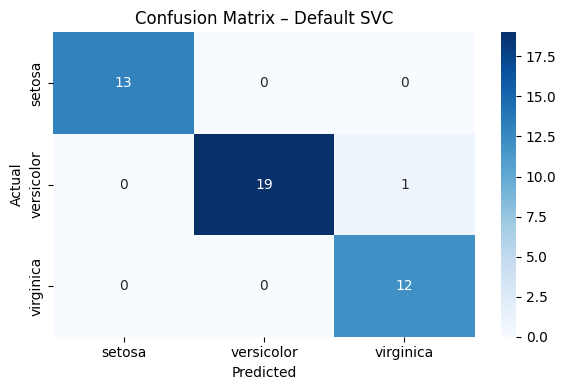

[[13  0  0]
 [ 0 19  1]
 [ 0  0 12]]


In [8]:
print('Confusion Matrix:')
cm = confusion_matrix(y_test, predictions)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svc.classes_, yticklabels=svc.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix – Default SVC')
plt.tight_layout()
plt.show()

print(cm)

In [9]:
print('Classification Report:')
print(classification_report(y_test, predictions))

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      0.95      0.97        20
   virginica       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



## 9. Hyperparameter Tuning with GridSearchCV

We search over a grid of `C` (regularisation) and `gamma` (kernel bandwidth) values
using 5-fold cross-validation to find the best combination.


In [10]:
param_grid = {
    'C':     [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001]
}
print(param_grid)

{'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001]}


In [11]:
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2, cv=5)
grid.fit(X_train, y_train)
print('Best parameters found:', grid.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ..................................C=0.1, gamma=0.01; total time=   0.0s
[CV] END ..................................C=0.1

## 10. Evaluate the Tuned Model


In [12]:
grid_predictions = grid.predict(X_test)
print(grid_predictions)

['setosa' 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica'
 'versicolor' 'versicolor' 'virginica' 'setosa' 'virginica' 'setosa'
 'setosa' 'virginica' 'virginica' 'versicolor' 'versicolor' 'versicolor'
 'setosa' 'virginica' 'versicolor' 'setosa' 'versicolor' 'versicolor'
 'versicolor' 'versicolor' 'versicolor' 'virginica' 'setosa' 'setosa'
 'virginica' 'versicolor' 'virginica' 'versicolor' 'virginica'
 'versicolor' 'versicolor' 'versicolor' 'versicolor' 'virginica' 'setosa'
 'setosa' 'setosa' 'virginica' 'versicolor']


Confusion Matrix (GridSearch SVC):


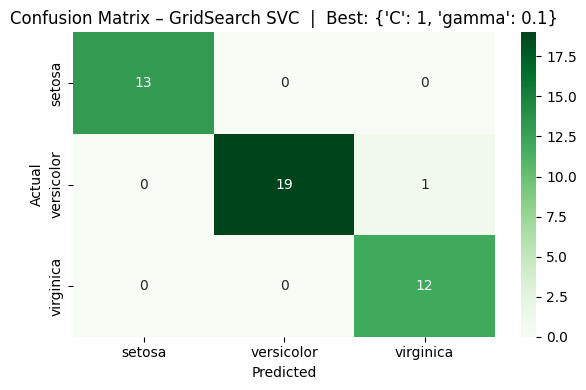

[[13  0  0]
 [ 0 19  1]
 [ 0  0 12]]


In [13]:
print('Confusion Matrix (GridSearch SVC):')
cm2 = confusion_matrix(y_test, grid_predictions)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=grid.classes_, yticklabels=grid.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix – GridSearch SVC  |  Best: {grid.best_params_}')
plt.tight_layout()
plt.show()

print(cm2)

In [14]:
print('Classification Report (GridSearch SVC):')
print(classification_report(y_test, grid_predictions))

Classification Report (GridSearch SVC):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      0.95      0.97        20
   virginica       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



## 11. Did GridSearchCV Improve the Model?

In this case, **GridSearchCV did not meaningfully improve the model** beyond the default SVC.
Both models achieved **98% overall accuracy** on the test set (44 / 45 correct), with
identical confusion matrices.

This outcome is expected for the Iris dataset because:

* The dataset is small (150 rows) and relatively clean — the default RBF kernel already
  finds a near-optimal boundary.
* The single misclassification (one *versicolor* predicted as *virginica*) lies in the
  genuine overlap zone between the two species; no choice of `C` or `gamma` removes it.

On a noisier or higher-dimensional dataset, GridSearch would typically provide a more
noticeable gain by preventing under- or over-fitting.

**Best parameters found by GridSearch:** `{'C': 1, 'gamma': 0.1}`
